# Model Comparison Notebook v3 - FIXED THRESHOLD MODE

> **Tujuan:** menghasilkan data mode threshold fixed (UP=55, DOWN=155) untuk tabel
> perbandingan fixed vs adaptive di BAB IV. Basis: v3 pixel fix, satu-satunya perubahan
> adalah `USE_ADAPTIVE = False` di Cell 4 (adaptive thresholding dimatikan).
>

>
> MAE/RMSE hasil run ini harus sama dengan run adaptive (threshold tidak mempengaruhi
> akurasi sudut). Yang berubah hanya rep count.

**Henry Abimanyu Dewandani | 1301220283 | Universitas Telkom**

In [1]:
# ============================================================
# CELL 1 -- Instalasi Dependensi
# Instalasi MediaPipe, YOLOv8 (Ultralytics), dan library pendukung.
# Pin mediapipe==0.10.21: versi terakhir yang masih punya solutions API
# (mp.solutions.pose). Versi 0.10.22+ menghapus API tersebut.
# ============================================================

import sys

# MediaPipe - pin ke versi yang masih support mp.solutions.pose
get_ipython().system(f'"{sys.executable}" -m pip install "mediapipe==0.10.21" --no-cache-dir -q')

# YOLOv8 dan library lain
get_ipython().system(f'"{sys.executable}" -m pip install ultralytics scipy matplotlib seaborn openpyxl -q')


print("Dependencies installed.")
print("Restart kernel sekarang: Kernel -> Restart Kernel")
print("Setelah restart, jalankan dari Cell 2.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Dependencies installed.
Restart kernel sekarang: Kernel -> Restart Kernel
Setelah restart, jalankan dari Cell 2.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.4.6 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
# ============================================================
# CELL 2 -- Import Library
# Import seluruh library yang dibutuhkan untuk proses komparasi.
# ============================================================

import sys, importlib
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import time
import os
import math
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import deque
from scipy.signal import savgol_filter
from ultralytics import YOLO
from IPython.display import display, HTML
from base64 import b64encode

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f' Imports OK')
print(f'   Python     : {sys.executable}')
print(f'   mediapipe  : {mp.__version__}')
print(f'   Environment: {"Google Colab" if IN_COLAB else "Local"}')

 Imports OK
   Python     : C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
   mediapipe  : 0.10.14
   Environment: Local


In [13]:
# ============================================================
# CELL 3 -- Fungsi Pembantu (Helper Functions)
# Berisi: calculate_angle, smooth_savgol, detect_reps,
#         draw_angle_arc, compute_mae, compute_rmse
# ============================================================

def calculate_angle(a, b, c):
    """Hitung sudut siku (atan2 method). Input: [x,y] koordinat."""
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    if angle > 180.0:
        angle = 360.0 - angle
    return float(angle)


def smooth_savgol(buffer, window=9, poly=2):
    """Savitzky-Golay smoothing. Fallback ke mean jika data kurang."""
    arr = np.array(buffer)
    if len(arr) < window:
        return float(np.mean(arr)) if len(arr) > 0 else 0.0
    return float(savgol_filter(arr, window_length=window, polyorder=poly)[-1])


def detect_reps(angle_series, down_thresh=155, up_thresh=55):
    """
    Hitung jumlah repetisi dari time-series sudut.
    Algoritma: state machine DOWN → UP → DOWN = 1 rep
    Digunakan untuk kedua model agar algoritma counting-nya identik.
    """
    stage = 'netral'
    rep_count = 0
    for angle in angle_series:
        if angle > down_thresh:
            stage = 'down'
        if angle < up_thresh and stage == 'down':
            stage = 'up'
            rep_count += 1
    return rep_count



def compute_adaptive_thresholds(angle_series, flex_pct=0.15, ext_pct=0.10):
    """
    Hitung threshold UP dan DOWN secara adaptif dari range sudut aktual.
    Tiap model mendapat threshold sendiri berdasarkan output angle-nya,
    sehingga perbandingan rep counting menjadi adil.

    flex_pct : buffer di atas angle minimum  (threshold UP / fleksi)
    ext_pct  : buffer di bawah angle maksimum (threshold DOWN / ekstensi)
    """
    if not angle_series:
        return 55.0, 155.0   # fallback ke default jika tidak ada data
    arr = np.array(angle_series)
    # Gunakan percentile ke-5 dan ke-95 agar robust terhadap outlier
    angle_min = float(np.percentile(arr, 5))
    angle_max = float(np.percentile(arr, 95))
    angle_range = angle_max - angle_min
    up_thresh   = round(angle_min + angle_range * flex_pct, 1)
    down_thresh = round(angle_max - angle_range * ext_pct,  1)
    return up_thresh, down_thresh


def draw_angle_arc(image, b_px, a_px, c_px, angle,
                   color=(0,255,255), radius=40):
    """Gambar busur sudut di titik siku."""
    try:
        v1 = np.array(a_px, dtype=float) - np.array(b_px, dtype=float)
        v2 = np.array(c_px, dtype=float) - np.array(b_px, dtype=float)
        a1 = math.degrees(math.atan2(v1[1], v1[0]))
        a2 = math.degrees(math.atan2(v2[1], v2[0]))
        s, e = min(a1, a2), max(a1, a2)
        if e - s > 180: s, e = e, s + 360
        cv2.ellipse(image, tuple(map(int, b_px)), (radius, radius),
                    0, s, e, color, 2)
        cv2.putText(image, f"{int(angle)}d",
                    (int(b_px[0])+radius+4, int(b_px[1])),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    except Exception:
        pass


def compute_mae(predicted, ground_truth):
    """
    Hitung MAE antara prediksi sistem dan ground truth manual.
    Input: list of (frame_idx, angle) pairs yang cocok.
    """
    if not predicted or not ground_truth:
        return None
    gt_dict = {f: a for f, a in ground_truth}
    errors = []
    for f, a in predicted:
        if f in gt_dict:
            errors.append(abs(a - gt_dict[f]))
    return float(np.mean(errors)) if errors else None


def compute_rmse(predicted, ground_truth):
    """
    Hitung RMSE antara prediksi sistem dan ground truth manual.
    Input: list of (frame_idx, angle) pairs yang cocok.
    """
    if not predicted or not ground_truth:
        return None
    gt_dict = {f: a for f, a in ground_truth}
    errors = []
    for f, a in predicted:
        if f in gt_dict:
            errors.append((a - gt_dict[f]) ** 2)
    return float(np.sqrt(np.mean(errors))) if errors else None


print(' Helper functions loaded')

 Helper functions loaded


In [14]:
# ============================================================
# CELL 4 -- Upload Video dan Inisialisasi Ground Truth Awal
# Upload video mentah Bicep Curl dan set GROUND_TRUTH_ANGLES
# placeholder. Nilai ini akan diganti di Cell 6 (Hybrid GT).
# ============================================================

# --- Upload / pilih video ---
print(" Upload video Bicep Curl untuk komparasi (MP4):")
if IN_COLAB:
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("Tidak ada file yang diupload!")
    VIDEO_PATH = list(uploaded.keys())[0]
else:
    VIDEO_PATH = input("Masukkan path lengkap ke file video MP4: ").strip().strip('"')
    if not os.path.exists(VIDEO_PATH):
        raise FileNotFoundError(f"File tidak ditemukan: {VIDEO_PATH}")

cap_info = cv2.VideoCapture(VIDEO_PATH)
FPS          = cap_info.get(cv2.CAP_PROP_FPS) or 30.0
VID_WIDTH    = int(cap_info.get(cv2.CAP_PROP_FRAME_WIDTH))  or 640
VID_HEIGHT   = int(cap_info.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 480
TOTAL_FRAMES = int(cap_info.get(cv2.CAP_PROP_FRAME_COUNT))
cap_info.release()

print(f" Video: {VIDEO_PATH}")
print(f"   {VID_WIDTH}x{VID_HEIGHT} @ {FPS:.1f}fps | {TOTAL_FRAMES} frames ({TOTAL_FRAMES/FPS:.1f}s)")

# -------------------------------------------------------------------
# GROUND TRUTH - Isi manual setelah mengukur sudut di frame sampel
# -------------------------------------------------------------------
# Format: list of (frame_number, angle_degrees)
# Cara pengukuran: buka video di software (VLC/video editor),
# screenshot frame tertentu, ukur sudut siku dengan ImageJ atau Protractor.
#
# Minimal 10 - 15 frame untuk hasil MAE yang valid secara statistik.
# Pilih frame yang tersebar merata: posisi ekstensi, mid-curl, fleksi puncak.
#
# Contoh format :
GROUND_TRUTH_ANGLES = [
    ( 113,  165.057),  # ekstensi
    ( 159,   39.218),  # fleksi
    ( 312,   82.572),  # mid curl
    ( 330,   40.979),  # fleksi
    ( 355,  108.225),  # eksentrik
    ( 403,   85.997),  # mid curl
    ( 409,   65.261),  # konsentrik
    ( 507,   61.792),  # konsentrik
    ( 545,  112.782),  # eksentrik
    ( 571,  164.272),  # ekstensi
    ( 600,   79.325),  # mid curl
    ( 604,   67.887),  # konsentrik
    ( 618,   40.747),  # fleksi
    ( 643,  120.403),  # eksentrik
    ( 687,  157.061),  # ekstensi
]
MANUAL_REP_COUNT = 8

# Mode threshold: False = fixed UP=55/DOWN=155 (untuk tabel fixed vs adaptive BAB IV)
USE_ADAPTIVE = False

print(f"\n Ground truth: {len(GROUND_TRUTH_ANGLES)} frame terukur | {MANUAL_REP_COUNT} reps manual")
if len(GROUND_TRUTH_ANGLES) < 15:
    print("  Rekomendasi: ukur minimal 15 frame untuk MAE yang reliable")

OUTPUT_DIR = "/content/comparison_outputs_v3_fixed" if IN_COLAB else os.path.join(os.path.dirname(VIDEO_PATH), "comparison_outputs_v3_fixed")
os.makedirs(OUTPUT_DIR, exist_ok=True)

 Upload video Bicep Curl untuk komparasi (MP4):
 Video: C:\Users\ASUS\OneDrive\Documents\Claude\Projects\Seputar Tugas Akhir\Dataset video Bicep curl\video bicep curl occlusion.mp4
   1280x720 @ 30.0fps | 976 frames (32.5s)

 Ground truth: 15 frame terukur | 8 reps manual


In [15]:
# ============================================================
# CELL 5A -- Proses Model 1: MediaPipe BlazePose
# Ekstraksi landmark, perhitungan sudut siku, deteksi repetisi,
# dan penyimpanan hasil per frame ke bp_angles dan bp_results.
# ============================================================

print(" Memproses dengan MediaPipe BlazePose...")

mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

bp_results = []   # per-frame results
bp_angles  = []   # (frame_idx, smooth_angle)
bp_conf    = []   # confidence scores
bp_detected= 0    # frame berhasil dideteksi
angle_buf  = deque(maxlen=11)

out_bp_path = os.path.join(OUTPUT_DIR, "output_blazepose.mp4")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_bp = cv2.VideoWriter(out_bp_path, fourcc, FPS, (VID_WIDTH, VID_HEIGHT))

bp_start = time.time()

cap = cv2.VideoCapture(VIDEO_PATH)
with mp_pose.Pose(min_detection_confidence=0.6, min_tracking_confidence=0.6) as pose:
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1

        if frame_idx % 30 == 0:
            pct = frame_idx / TOTAL_FRAMES * 100
            print(f"\r  BlazePose [{('█'*int(pct//5)).ljust(20,'░')}] {pct:.0f}%", end='')

        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res       = pose.process(image_rgb)
        image     = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

        raw_angle = 0.0; smooth_angle = 0.0; conf = 0.0; detected = False

        if res.pose_landmarks:
            lm = res.pose_landmarks.landmark

            # Pilih sisi dengan visibility lebih tinggi
            r_vis = (lm[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].visibility +
                     lm[mp_pose.PoseLandmark.RIGHT_ELBOW.value].visibility +
                     lm[mp_pose.PoseLandmark.RIGHT_WRIST.value].visibility) / 3
            l_vis = (lm[mp_pose.PoseLandmark.LEFT_SHOULDER.value].visibility +
                     lm[mp_pose.PoseLandmark.LEFT_ELBOW.value].visibility +
                     lm[mp_pose.PoseLandmark.LEFT_WRIST.value].visibility) / 3

            if r_vis >= l_vis:
                s = lm[mp_pose.PoseLandmark.RIGHT_SHOULDER.value]
                e = lm[mp_pose.PoseLandmark.RIGHT_ELBOW.value]
                w = lm[mp_pose.PoseLandmark.RIGHT_WRIST.value]
                conf = r_vis
            else:
                s = lm[mp_pose.PoseLandmark.LEFT_SHOULDER.value]
                e = lm[mp_pose.PoseLandmark.LEFT_ELBOW.value]
                w = lm[mp_pose.PoseLandmark.LEFT_WRIST.value]
                conf = l_vis

            if conf >= 0.6:
                detected = True
                bp_detected += 1
                # v3: koreksi rasio aspek - koordinat ternormalisasi dikonversi ke pixel
                # agar sudut BlazePose satu ruang geometri dengan YOLOv8 dan GT ImageJ
                raw_angle = calculate_angle([s.x * VID_WIDTH, s.y * VID_HEIGHT],
                                            [e.x * VID_WIDTH, e.y * VID_HEIGHT],
                                            [w.x * VID_WIDTH, w.y * VID_HEIGHT])
                angle_buf.append(raw_angle)
                smooth_angle = smooth_savgol(angle_buf)
                bp_angles.append((frame_idx, smooth_angle))
                bp_conf.append(conf)

                # Visualisasi
                mp_drawing.draw_landmarks(
                    image, res.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                    mp_drawing.DrawingSpec(color=(255,100,0), thickness=2, circle_radius=3),
                    mp_drawing.DrawingSpec(color=(255,200,0), thickness=2)
                )
                e_px = (int(e.x*VID_WIDTH), int(e.y*VID_HEIGHT))
                s_px = (int(s.x*VID_WIDTH), int(s.y*VID_HEIGHT))
                w_px = (int(w.x*VID_WIDTH), int(w.y*VID_HEIGHT))
                draw_angle_arc(image, e_px, s_px, w_px, smooth_angle,
                               color=(0, 255, 255))

        # Overlay info
        cv2.rectangle(image, (5,5), (380,80), (0,0,0), -1)
        cv2.putText(image, "MODEL: MediaPipe BlazePose",
                    (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,150,0), 2)
        cv2.putText(image, f"Angle: {int(smooth_angle):>3}d | Conf: {conf:.2f} | F:{frame_idx}",
                    (10,60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
        out_bp.write(image)

        bp_results.append({
            'frame': frame_idx, 'detected': detected,
            'angle_raw': round(raw_angle, 2),
            'angle_smooth': round(smooth_angle, 2),
            'confidence': round(conf, 4)
        })

cap.release()
out_bp.release()

bp_elapsed = time.time() - bp_start
bp_fps     = TOTAL_FRAMES / bp_elapsed
bp_det_rate= bp_detected / TOTAL_FRAMES * 100
bp_angles_series = [a for _, a in bp_angles]
if USE_ADAPTIVE:
    bp_up_thresh, bp_down_thresh = compute_adaptive_thresholds(bp_angles_series)
else:
    bp_up_thresh, bp_down_thresh = 55.0, 155.0
bp_rep_count = detect_reps(bp_angles_series,
                           down_thresh=bp_down_thresh,
                           up_thresh=bp_up_thresh)
bp_mae = compute_mae(bp_angles, GROUND_TRUTH_ANGLES)
bp_avg_conf  = float(np.mean(bp_conf)) if bp_conf else 0.0

print(f"\n BlazePose selesai!")
print(f"   FPS          : {bp_fps:.1f}")
print(f"   Detection    : {bp_det_rate:.1f}% ({bp_detected}/{TOTAL_FRAMES} frames)")
print(f"   Threshold UP : {bp_up_thresh} deg | DOWN: {bp_down_thresh} deg "
      f"({'adaptive' if USE_ADAPTIVE else 'fixed'})")
print(f"   Rep Count    : {bp_rep_count} (manual: {MANUAL_REP_COUNT})")
print(f"   Avg Conf     : {bp_avg_conf:.3f}")
print(f"   MAE Sudut    : {f'{bp_mae:.2f}°' if bp_mae else 'N/A (isi ground truth dulu)'}")

 Memproses dengan MediaPipe BlazePose...


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  BlazePose [███████████████████░] 98%
 BlazePose selesai!
   FPS          : 44.9
   Detection    : 100.0% (976/976 frames)
   Threshold UP : 55.0 deg | DOWN: 155.0 deg (fixed)
   Rep Count    : 8 (manual: 8)
   Avg Conf     : 0.913
   MAE Sudut    : 9.98°


In [16]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

CUDA available: False
PyTorch version: 2.12.0+cpu
CUDA version: None


In [17]:
# ============================================================
# CELL 5B -- Proses Model 2: YOLOv8-Pose (Medium)
# Ekstraksi keypoint COCO, perhitungan sudut siku, deteksi
# repetisi, dan penyimpanan hasil ke yolo_angles dan yolo_results.
# ============================================================

# YOLOv8-Pose menggunakan format COCO 17 keypoints:
# Indeks relevan untuk Bicep Curl:
#   5 = LEFT_SHOULDER  |  6 = RIGHT_SHOULDER
#   7 = LEFT_ELBOW     |  8 = RIGHT_ELBOW
#   9 = LEFT_WRIST     | 10 = RIGHT_WRIST
# ============================================================

print(" Memproses dengan YOLOv8-Pose...")
print("   (Download model yolov8n-pose.pt jika belum ada...)")

# yolov8n-pose = nano (tercepat), yolov8m-pose = medium (lebih akurat)
# Untuk penelitian: gunakan yolov8m-pose untuk akurasi terbaik
YOLO_MODEL = "yolov8m-pose.pt"   # akan auto-download dari Ultralytics
yolo_model = YOLO(YOLO_MODEL)

# Indeks keypoint COCO
COCO_R_SHOULDER = 6
COCO_L_SHOULDER = 5
COCO_R_ELBOW    = 8
COCO_L_ELBOW    = 7
COCO_R_WRIST    = 10
COCO_L_WRIST    = 9

yolo_results = []
yolo_angles  = []
yolo_conf    = []
yolo_detected= 0
angle_buf_y  = deque(maxlen=11)

out_yolo_path = os.path.join(OUTPUT_DIR, "output_yolov8pose.mp4")
out_yolo = cv2.VideoWriter(out_yolo_path, fourcc, FPS, (VID_WIDTH, VID_HEIGHT))

yolo_start = time.time()
cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    frame_idx += 1

    if frame_idx % 30 == 0:
        pct = frame_idx / TOTAL_FRAMES * 100
        print(f"\r  YOLOv8 [{('█'*int(pct//5)).ljust(20,'░')}] {pct:.0f}%", end='')

    image = frame.copy()
    raw_angle = 0.0; smooth_angle = 0.0; conf = 0.0; detected = False

    # Inferensi YOLO - verbose=False untuk suppress output
    yolo_res = yolo_model(frame, verbose=False, conf=0.5)

    if yolo_res and len(yolo_res[0].keypoints.data) > 0:
        kps = yolo_res[0].keypoints.data[0]  # orang pertama (single person)
        # kps shape: [17, 3] -> (x, y, confidence)

        # Pilih sisi aktif berdasarkan confidence keypoint
        r_conf_avg = (kps[COCO_R_SHOULDER][2] + kps[COCO_R_ELBOW][2] + kps[COCO_R_WRIST][2]) / 3
        l_conf_avg = (kps[COCO_L_SHOULDER][2] + kps[COCO_L_ELBOW][2] + kps[COCO_L_WRIST][2]) / 3

        if r_conf_avg >= l_conf_avg:
            s_kp = kps[COCO_R_SHOULDER]
            e_kp = kps[COCO_R_ELBOW]
            w_kp = kps[COCO_R_WRIST]
            conf = float(r_conf_avg)
        else:
            s_kp = kps[COCO_L_SHOULDER]
            e_kp = kps[COCO_L_ELBOW]
            w_kp = kps[COCO_L_WRIST]
            conf = float(l_conf_avg)

        if conf >= 0.5 and s_kp[2] > 0 and e_kp[2] > 0 and w_kp[2] > 0:
            detected = True
            yolo_detected += 1

            # YOLO keypoints dalam pixel absolut (bukan normalized)
            shoulder = [float(s_kp[0]), float(s_kp[1])]
            elbow    = [float(e_kp[0]), float(e_kp[1])]
            wrist    = [float(w_kp[0]), float(w_kp[1])]

            raw_angle = calculate_angle(shoulder, elbow, wrist)
            angle_buf_y.append(raw_angle)
            smooth_angle = smooth_savgol(angle_buf_y)
            yolo_angles.append((frame_idx, smooth_angle))
            yolo_conf.append(conf)

            # Gambar skeleton YOLO
            annotated = yolo_res[0].plot()
            image = annotated

            # Arc sudut di siku
            e_px = (int(elbow[0]), int(elbow[1]))
            s_px = (int(shoulder[0]), int(shoulder[1]))
            w_px = (int(wrist[0]), int(wrist[1]))
            draw_angle_arc(image, e_px, s_px, w_px, smooth_angle,
                           color=(0, 200, 255))

    # Overlay info
    cv2.rectangle(image, (5,5), (380,80), (0,0,0), -1)
    cv2.putText(image, "MODEL: YOLOv8-Pose (Medium)",
                (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,200,255), 2)
    cv2.putText(image, f"Angle: {int(smooth_angle):>3}d | Conf: {conf:.2f} | F:{frame_idx}",
                (10,60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
    out_yolo.write(image)

    yolo_results.append({
        'frame': frame_idx, 'detected': detected,
        'angle_raw': round(raw_angle, 2),
        'angle_smooth': round(smooth_angle, 2),
        'confidence': round(conf, 4)
    })

cap.release()
out_yolo.release()

yolo_elapsed = time.time() - yolo_start
yolo_fps      = TOTAL_FRAMES / yolo_elapsed
yolo_det_rate = yolo_detected / TOTAL_FRAMES * 100
yolo_angles_series = [a for _, a in yolo_angles]
if USE_ADAPTIVE:
    yolo_up_thresh, yolo_down_thresh = compute_adaptive_thresholds(yolo_angles_series)
else:
    yolo_up_thresh, yolo_down_thresh = 55.0, 155.0
yolo_rep_count = detect_reps(yolo_angles_series,
                             down_thresh=yolo_down_thresh,
                             up_thresh=yolo_up_thresh)
yolo_mae = compute_mae(yolo_angles, GROUND_TRUTH_ANGLES)
yolo_avg_conf = float(np.mean(yolo_conf)) if yolo_conf else 0.0

print(f"\n YOLOv8-Pose selesai!")
print(f"   FPS          : {yolo_fps:.1f}")
print(f"   Detection    : {yolo_det_rate:.1f}% ({yolo_detected}/{TOTAL_FRAMES} frames)")
print(f"   Threshold UP : {yolo_up_thresh} deg | DOWN: {yolo_down_thresh} deg "
      f"({'adaptive' if USE_ADAPTIVE else 'fixed'})")
print(f"   Rep Count    : {yolo_rep_count} (manual: {MANUAL_REP_COUNT})")
print(f"   Avg Conf     : {yolo_avg_conf:.3f}")
print(f"   MAE Sudut    : {f'{yolo_mae:.2f}°' if yolo_mae else 'N/A (isi ground truth dulu)'}")

 Memproses dengan YOLOv8-Pose...
   (Download model yolov8n-pose.pt jika belum ada...)
  YOLOv8 [███████████████████░] 98%
 YOLOv8-Pose selesai!
   FPS          : 6.0
   Detection    : 100.0% (976/976 frames)
   Threshold UP : 55.0 deg | DOWN: 155.0 deg (fixed)
   Rep Count    : 8 (manual: 8)
   Avg Conf     : 0.962
   MAE Sudut    : 11.04°


In [18]:
# ============================================================
# CELL 6 -- Kalkulasi MAE & RMSE vs Ground Truth ImageJ Manual
# MAE dan RMSE kedua model dihitung menggunakan GROUND_TRUTH_ANGLES
# yang berasal dari pengukuran manual menggunakan ImageJ
# pada 15 frame terpilih (stratified sampling 5 fase x 3 rep).
# Dijalankan setelah Cell 5A dan 5B selesai.
# ============================================================

print("Menghitung MAE & RMSE vs Ground Truth ImageJ Manual...")
print(f"   GT yang digunakan: {len(GROUND_TRUTH_ANGLES)} frame")

bp_mae    = compute_mae(bp_angles,   GROUND_TRUTH_ANGLES)
yolo_mae  = compute_mae(yolo_angles, GROUND_TRUTH_ANGLES)

bp_rmse   = compute_rmse(bp_angles,  GROUND_TRUTH_ANGLES)
yolo_rmse = compute_rmse(yolo_angles, GROUND_TRUTH_ANGLES)

print(f"\nHASIL ERROR METRICS VS GROUND TRUTH (ImageJ Manual):")
print(f"{'Metrik':<25} {'BlazePose':>12} {'YOLOv8-Pose':>12}")
print("-" * 50)
print(f"{'MAE Sudut Siku (°)':<25} {bp_mae:>12.2f} {yolo_mae:>12.2f}")
print(f"{'RMSE Sudut Siku (°)':<25} {bp_rmse:>12.2f} {yolo_rmse:>12.2f}")
print(f"{'Selisih MAE (°)':<25} {abs(yolo_mae - bp_mae):>12.2f} {'':>12}")
print(f"{'Selisih RMSE (°)':<25} {abs(yolo_rmse - bp_rmse):>12.2f} {'':>12}")
print("-" * 50)
print(f"\n   Catatan: RMSE > MAE menunjukkan adanya frame dengan error besar (outlier).")
print(f"   Selisih RMSE-MAE BlazePose : {bp_rmse - bp_mae:.2f}°")
print(f"   Selisih RMSE-MAE YOLOv8    : {yolo_rmse - yolo_mae:.2f}°")


Menghitung MAE & RMSE vs Ground Truth ImageJ Manual...
   GT yang digunakan: 15 frame

HASIL ERROR METRICS VS GROUND TRUTH (ImageJ Manual):
Metrik                       BlazePose  YOLOv8-Pose
--------------------------------------------------
MAE Sudut Siku (°)                9.98        11.04
RMSE Sudut Siku (°)              10.63        11.69
Selisih MAE (°)                   1.07             
Selisih RMSE (°)                  1.06             
--------------------------------------------------

   Catatan: RMSE > MAE menunjukkan adanya frame dengan error besar (outlier).
   Selisih RMSE-MAE BlazePose : 0.65°
   Selisih RMSE-MAE YOLOv8    : 0.65°


In [19]:
# ── Helper: export DataFrame ke Excel tabel terformat ─────────────────────────
def save_xlsx_table(df, path, sheet_name='Data', col_rename=None,
                    table_name='TableData', style='TableStyleMedium9'):
    from openpyxl.utils import get_column_letter
    from openpyxl.worksheet.table import Table, TableStyleInfo

    df_out = df.copy()
    if col_rename:
        df_out = df_out.rename(columns=col_rename)

    with pd.ExcelWriter(path, engine='openpyxl') as writer:
        df_out.to_excel(writer, index=False, sheet_name=sheet_name)
        ws = writer.sheets[sheet_name]

        n_rows   = len(df_out) + 1
        last_col = get_column_letter(len(df_out.columns))
        tab = Table(displayName=table_name, ref=f"A1:{last_col}{n_rows}")
        tab.tableStyleInfo = TableStyleInfo(
            name=style, showFirstColumn=False, showLastColumn=False,
            showRowStripes=True, showColumnStripes=False
        )
        ws.add_table(tab)

        for col in ws.columns:
            col_letter = get_column_letter(col[0].column)
            max_w = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[col_letter].width = min(max_w + 4, 35)

    return path

FRAMES_COL_RENAME = {
    'frame'       : 'Frame',
    'detected'    : 'Detected',
    'angle_raw'   : 'Angle Raw (°)',
    'angle_smooth': 'Angle Smooth (°)',
    'confidence'  : 'Confidence',
}

# ============================================================
# CELL 7 -- Tabel Komparasi Model
# Menyusun dan mencetak tabel perbandingan metrik lengkap:
# FPS, Detection Rate, Confidence, Rep Count, MAE, RMSE, Ukuran Model.
# Output: CSV (backup) + XLSX terformat.
# Hasil disimpan ke comparison_table.csv.
# ============================================================

# Hitung akurasi rep count
def rep_accuracy(pred, manual):
    if manual == 0: return 'N/A'
    return f"{(1 - abs(pred - manual) / manual) * 100:.1f}%"

bp_rep_acc   = rep_accuracy(bp_rep_count, MANUAL_REP_COUNT)
yolo_rep_acc = rep_accuracy(yolo_rep_count, MANUAL_REP_COUNT)

# Tabel ringkasan
comparison_data = {
    'Metrik'               : [
        'Framework',
        'Jumlah Landmark',
        'Format Koordinat',
        'Processing Speed (FPS)',
        'Detection Rate (%)',
        'Avg Confidence/Visibility',
        'Rep Count (sistem)',
        'Rep Count (manual)',
        'Akurasi Rep Count',
        'MAE Sudut Siku (°)',
        'RMSE Sudut Siku (°)',
        'Ukuran Model',
    ],
    'MediaPipe BlazePose'  : [
        'MediaPipe 0.10.14',
        '33 titik (3D)',
        'Normalized [0,1]',
        f"{bp_fps:.1f}",
        f"{bp_det_rate:.1f}%",
        f"{bp_avg_conf:.3f}",
        str(bp_rep_count),
        str(MANUAL_REP_COUNT),
        bp_rep_acc,
        f"{bp_mae:.2f}°" if bp_mae else 'N/A',
        f"{bp_rmse:.2f}°" if bp_rmse else 'N/A',
        '~25 MB',
    ],
    'YOLOv8-Pose (Medium)' : [
        'Ultralytics YOLOv8',
        '17 titik (COCO)',
        'Pixel absolut',
        f"{yolo_fps:.1f}",
        f"{yolo_det_rate:.1f}%",
        f"{yolo_avg_conf:.3f}",
        str(yolo_rep_count),
        str(MANUAL_REP_COUNT),
        yolo_rep_acc,
        f"{yolo_mae:.2f}°" if yolo_mae else 'N/A',
        f"{yolo_rmse:.2f}°" if yolo_rmse else 'N/A',
        '~52 MB',
    ]
}

df_comp = pd.DataFrame(comparison_data)
print("\n" + "="*75)
print("   TABEL KOMPARASI MODEL - MediaPipe BlazePose vs YOLOv8-Pose")
print("="*75)
print(df_comp.to_string(index=False))
print("="*75)

# Simpan tabel komparasi - CSV (backup) + XLSX (utama)
comp_csv  = os.path.join(OUTPUT_DIR, "comparison_table.csv")
comp_xlsx = os.path.join(OUTPUT_DIR, "comparison_table.xlsx")
df_comp.to_csv(comp_csv, index=False, encoding='utf-8-sig')
save_xlsx_table(df_comp, comp_xlsx, sheet_name='Komparasi',
                table_name='KomparasiModel', style='TableStyleMedium2')
print(f"\n Tabel komparasi: {comp_csv}")
print(f"                  {comp_xlsx}")

# Simpan frame-level data - CSV (backup) + XLSX (utama)
df_bp   = pd.DataFrame(bp_results)
df_yolo = pd.DataFrame(yolo_results)

df_bp.to_csv(os.path.join(OUTPUT_DIR, 'frames_blazepose.csv'), index=False, encoding='utf-8-sig')
save_xlsx_table(df_bp, os.path.join(OUTPUT_DIR, 'frames_blazepose.xlsx'),
                sheet_name='BlazePose', col_rename=FRAMES_COL_RENAME,
                table_name='BlazePoseData', style='TableStyleMedium9')

df_yolo.to_csv(os.path.join(OUTPUT_DIR, 'frames_yolov8pose.csv'), index=False, encoding='utf-8-sig')
save_xlsx_table(df_yolo, os.path.join(OUTPUT_DIR, 'frames_yolov8pose.xlsx'),
                sheet_name='YOLOv8Pose', col_rename=FRAMES_COL_RENAME,
                table_name='YOLOv8Data', style='TableStyleMedium4')

print(" Frame-level CSV + XLSX kedua model disimpan")


   TABEL KOMPARASI MODEL - MediaPipe BlazePose vs YOLOv8-Pose
                   Metrik MediaPipe BlazePose YOLOv8-Pose (Medium)
                Framework   MediaPipe 0.10.14   Ultralytics YOLOv8
          Jumlah Landmark       33 titik (3D)      17 titik (COCO)
         Format Koordinat    Normalized [0,1]        Pixel absolut
   Processing Speed (FPS)                44.9                  6.0
       Detection Rate (%)              100.0%               100.0%
Avg Confidence/Visibility               0.913                0.962
       Rep Count (sistem)                   8                    8
       Rep Count (manual)                   8                    8
        Akurasi Rep Count              100.0%               100.0%
       MAE Sudut Siku (°)               9.98°               11.04°
      RMSE Sudut Siku (°)              10.63°               11.69°
             Ukuran Model              ~25 MB               ~52 MB

 Tabel komparasi: C:\Users\ASUS\OneDrive\Documents\Claude\Project

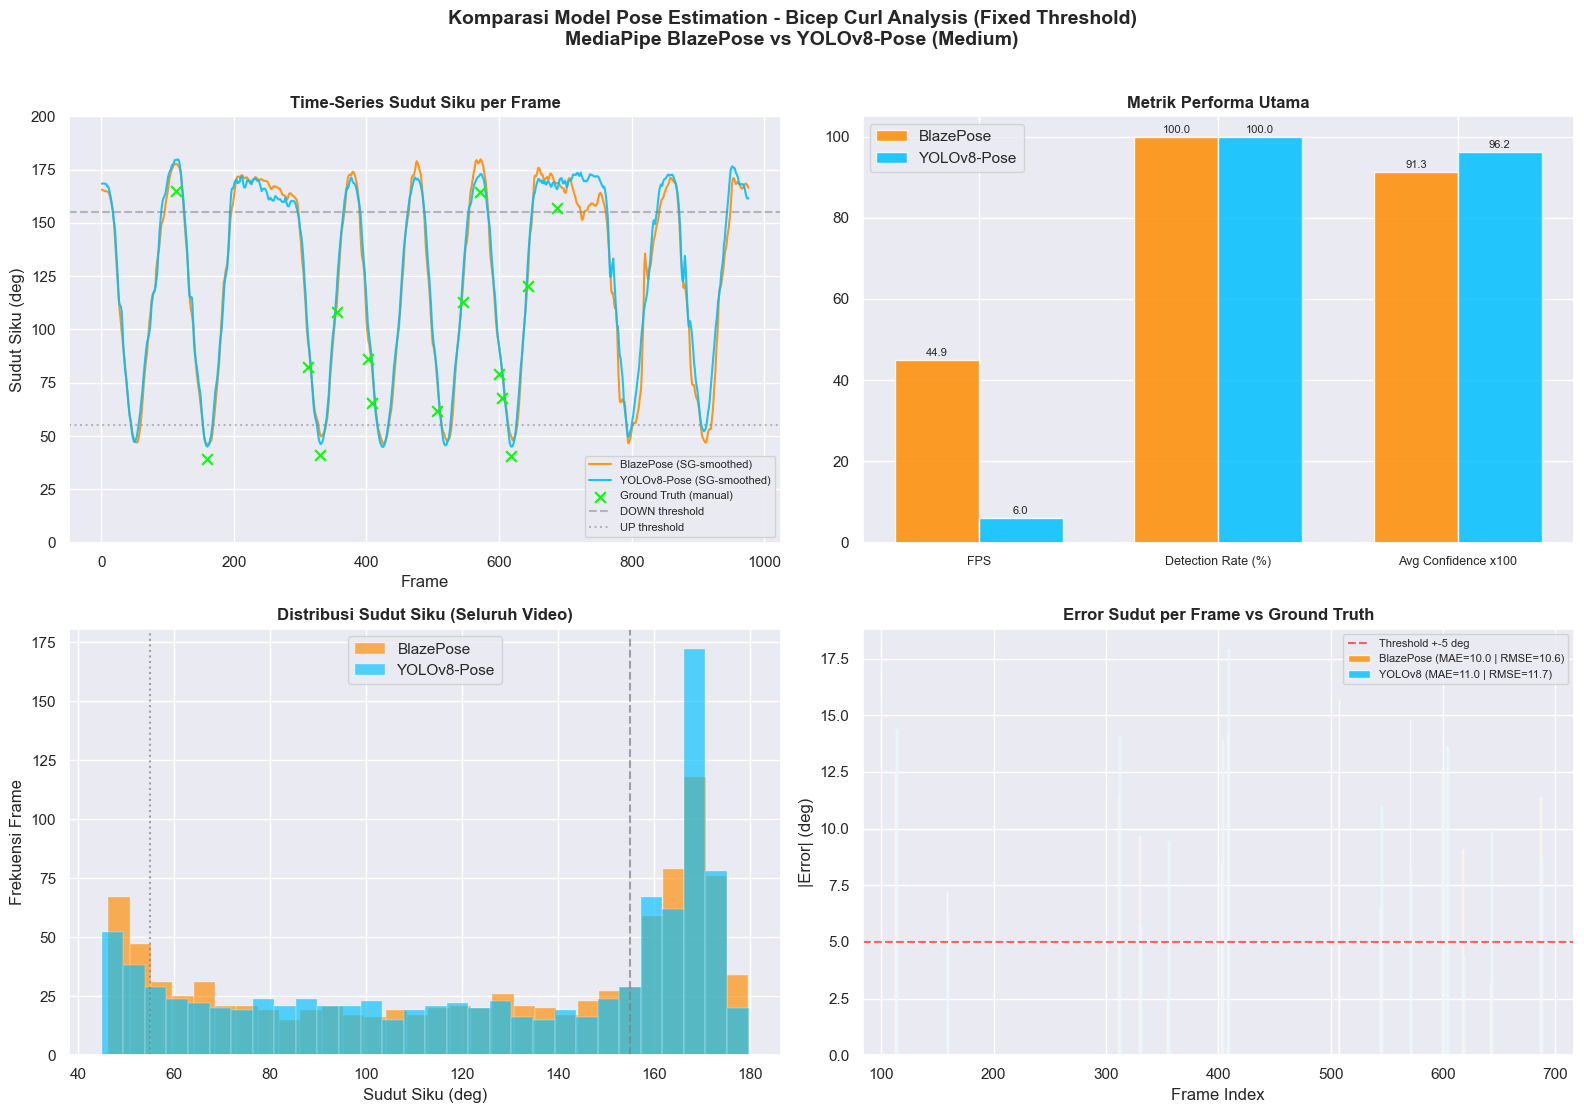

 Grafik komparasi disimpan: C:\Users\ASUS\OneDrive\Documents\Claude\Projects\Seputar Tugas Akhir\Dataset video Bicep curl\comparison_outputs_v3_fixed\comparison_chart.png


In [20]:
# ============================================================
# CELL 8 -- Visualisasi Grafik Komparasi
# Menghasilkan 4 grafik: time-series sudut, bar chart metrik,
# distribusi sudut (histogram), dan error per frame vs GT.
# Hasil disimpan ke comparison_chart.png.
# ============================================================

sns.set_theme(style='darkgrid', palette='muted')
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Komparasi Model Pose Estimation - Bicep Curl Analysis (Fixed Threshold)\n'
             'MediaPipe BlazePose vs YOLOv8-Pose (Medium)',
             fontsize=14, fontweight='bold', y=1.01)

# --- Plot 1: Time-series sudut kedua model ---
ax1 = axes[0, 0]
if bp_angles:
    bp_frames, bp_ang = zip(*bp_angles)
    ax1.plot(bp_frames, bp_ang, color='#FF8C00', linewidth=1.5,
             label='BlazePose (SG-smoothed)', alpha=0.9)
if yolo_angles:
    yo_frames, yo_ang = zip(*yolo_angles)
    ax1.plot(yo_frames, yo_ang, color='#00BFFF', linewidth=1.5,
             label='YOLOv8-Pose (SG-smoothed)', alpha=0.9)
if GROUND_TRUTH_ANGLES:
    gt_frames, gt_ang = zip(*GROUND_TRUTH_ANGLES)
    ax1.scatter(gt_frames, gt_ang, color='lime', s=60, zorder=5,
                label='Ground Truth (manual)', marker='x')
ax1.axhline(y=155, color='gray', linestyle='--', alpha=0.5, label='DOWN threshold')
ax1.axhline(y=55,  color='gray', linestyle=':',  alpha=0.5, label='UP threshold')
ax1.set_title('Time-Series Sudut Siku per Frame', fontweight='bold')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Sudut Siku (deg)')
ax1.legend(fontsize=8)
ax1.set_ylim(0, 200)

# --- Plot 2: Bar chart metrik utama ---
ax2 = axes[0, 1]
metrics_names  = ['FPS', 'Detection Rate (%)', 'Avg Confidence x100']
bp_vals   = [bp_fps, bp_det_rate, bp_avg_conf * 100]
yolo_vals = [yolo_fps, yolo_det_rate, yolo_avg_conf * 100]
x = np.arange(len(metrics_names))
w = 0.35
bars1 = ax2.bar(x - w/2, bp_vals,   w, label='BlazePose',   color='#FF8C00', alpha=0.85)
bars2 = ax2.bar(x + w/2, yolo_vals, w, label='YOLOv8-Pose', color='#00BFFF', alpha=0.85)
ax2.set_title('Metrik Performa Utama', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names, fontsize=9)
ax2.legend()
for bar in bars1: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# --- Plot 3: Distribusi sudut (histogram) ---
ax3 = axes[1, 0]
if bp_angles_series:
    ax3.hist(bp_angles_series, bins=30, color='#FF8C00', alpha=0.65,
             label='BlazePose', edgecolor='white', linewidth=0.3)
if yolo_angles_series:
    ax3.hist(yolo_angles_series, bins=30, color='#00BFFF', alpha=0.65,
             label='YOLOv8-Pose', edgecolor='white', linewidth=0.3)
ax3.set_title('Distribusi Sudut Siku (Seluruh Video)', fontweight='bold')
ax3.set_xlabel('Sudut Siku (deg)')
ax3.set_ylabel('Frekuensi Frame')
ax3.legend()
ax3.axvline(x=55,  color='gray', linestyle=':', alpha=0.7, label='UP threshold')
ax3.axvline(x=155, color='gray', linestyle='--', alpha=0.7, label='DOWN threshold')

# --- Plot 4: MAE per frame (jika GT tersedia) ---
ax4 = axes[1, 1]
if GROUND_TRUTH_ANGLES and bp_angles and yolo_angles:
    gt_dict = {f: a for f, a in GROUND_TRUTH_ANGLES}
    bp_mae_pts   = [(f, abs(a - gt_dict[f])) for f, a in bp_angles if f in gt_dict]
    yolo_mae_pts = [(f, abs(a - gt_dict[f])) for f, a in yolo_angles if f in gt_dict]
    if bp_mae_pts:
        ax4.bar([p[0]-0.4 for p in bp_mae_pts],   [p[1] for p in bp_mae_pts],
                width=0.8, color='#FF8C00', alpha=0.8, label=f'BlazePose (MAE={bp_mae:.1f} | RMSE={bp_rmse:.1f})')
    if yolo_mae_pts:
        ax4.bar([p[0]+0.4 for p in yolo_mae_pts], [p[1] for p in yolo_mae_pts],
                width=0.8, color='#00BFFF', alpha=0.8, label=f'YOLOv8 (MAE={yolo_mae:.1f} | RMSE={yolo_rmse:.1f})')
    ax4.axhline(y=5, color='red', linestyle='--', alpha=0.6, label='Threshold +-5 deg')
    ax4.set_title('Error Sudut per Frame vs Ground Truth', fontweight='bold')
    ax4.set_xlabel('Frame Index')
    ax4.set_ylabel('|Error| (deg)')
    ax4.legend(fontsize=8)
else:
    ax4.text(0.5, 0.5,
             'Plot MAE tidak tersedia.\nIsi GROUND_TRUTH_ANGLES\ndi Cell 4 terlebih dahulu.',
             ha='center', va='center', transform=ax4.transAxes,
             fontsize=11, color='gray',
             bbox=dict(boxstyle='round', facecolor='#222', alpha=0.5))
    ax4.set_title('Error Sudut per Frame vs Ground Truth', fontweight='bold')
    ax4.set_facecolor('#1a1a1a')

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, 'comparison_chart.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" Grafik komparasi disimpan: {chart_path}")

In [21]:
# ============================================================
# CELL 9 -- Kesimpulan dan Download Output
# Menentukan pemenang per metrik, skor total, dan model
# yang direkomendasikan berdasarkan konteks penggunaan.
# Detection Rate dianggap seri jika selisih < 2%.
# ============================================================

print("\n" + "="*65)
print("   ANALISIS KOMPARASI (FIXED THRESHOLD) -- KESIMPULAN")
print("="*65)

def tentukan_pemenang(bp_val, yolo_val, higher_is_better=True,
                      threshold_seri=None):
    """
    Bandingkan dua nilai dan kembalikan pemenang atau 'Seri'.
    threshold_seri: jika selisih absolut <= threshold, dianggap Seri.
    """
    if bp_val == yolo_val:
        return 'Seri'
    if threshold_seri is not None:
        if abs(bp_val - yolo_val) <= threshold_seri:
            return 'Seri'
    if higher_is_better:
        return 'BlazePose' if bp_val > yolo_val else 'YOLOv8-Pose'
    else:
        return 'BlazePose' if bp_val < yolo_val else 'YOLOv8-Pose'


winner_fps  = tentukan_pemenang(bp_fps, yolo_fps, higher_is_better=True)
winner_det  = tentukan_pemenang(bp_det_rate, yolo_det_rate,
                                higher_is_better=True, threshold_seri=2.0)
winner_conf = tentukan_pemenang(bp_avg_conf, yolo_avg_conf,
                                higher_is_better=True)

if bp_mae and yolo_mae:
    winner_mae = tentukan_pemenang(bp_mae, yolo_mae, higher_is_better=False)
    mae_label  = (f"BlazePose ({bp_mae:.2f} deg) vs "
                  f"YOLOv8-Pose ({yolo_mae:.2f} deg)")
else:
    winner_mae = 'N/A'
    mae_label  = 'Ground truth belum diisi'

bp_rep_diff   = abs(bp_rep_count   - MANUAL_REP_COUNT)
yolo_rep_diff = abs(yolo_rep_count - MANUAL_REP_COUNT)
winner_rep    = tentukan_pemenang(bp_rep_diff, yolo_rep_diff,
                                  higher_is_better=False)
rep_label     = (f"BlazePose ({bp_rep_count}/{MANUAL_REP_COUNT}, "
                 f"acc={bp_rep_acc}) vs "
                 f"YOLOv8-Pose ({yolo_rep_count}/{MANUAL_REP_COUNT}, "
                 f"acc={yolo_rep_acc})")

print(f"  Kecepatan (FPS)       : {winner_fps:<12}"
      f"  ({bp_fps:.1f} vs {yolo_fps:.1f})")
print(f"  Detection Rate        : {winner_det:<12}"
      f"  ({bp_det_rate:.1f}% vs {yolo_det_rate:.1f}%,"
      f" selisih <2% dianggap seri)")
print(f"  Akurasi Sudut (MAE)   : {winner_mae:<12}  {mae_label}")
print(f"  Rep Count             : {winner_rep:<12}  {rep_label}")
print()
print("  CATATAN: Run ini memakai threshold FIXED (UP=55, DOWN=155)")
print("  tanpa adaptive thresholding. Hasilnya dipakai untuk tabel")
print("  perbandingan fixed vs adaptive di BAB IV, bukan untuk")
print("  kesimpulan pemilihan model.")
print()
print("  Catatan MAE: Ground truth diukur manual menggunakan ImageJ")
print("  dari 15 frame terpilih secara stratified sampling (3 frame")
print("  per fase: Ekstensi, Konsentrik, Mid-curl, Eksentrik, Fleksi).")
print("  MAE/RMSE tidak dipengaruhi mode threshold, angkanya harus")
print("  sama dengan run adaptive. Jika beda jauh, ada yang salah.")
print("="*65)
print(f"\nSemua output tersimpan di: {OUTPUT_DIR}")


   ANALISIS KOMPARASI (FIXED THRESHOLD) -- KESIMPULAN
  Kecepatan (FPS)       : BlazePose     (44.9 vs 6.0)
  Detection Rate        : Seri          (100.0% vs 100.0%, selisih <2% dianggap seri)
  Akurasi Sudut (MAE)   : BlazePose     BlazePose (9.98 deg) vs YOLOv8-Pose (11.04 deg)
  Rep Count             : Seri          BlazePose (8/8, acc=100.0%) vs YOLOv8-Pose (8/8, acc=100.0%)

  CATATAN: Run ini memakai threshold FIXED (UP=55, DOWN=155)
  tanpa adaptive thresholding. Hasilnya dipakai untuk tabel
  perbandingan fixed vs adaptive di BAB IV, bukan untuk
  kesimpulan pemilihan model.

  Catatan MAE: Ground truth diukur manual menggunakan ImageJ
  dari 15 frame terpilih secara stratified sampling (3 frame
  per fase: Ekstensi, Konsentrik, Mid-curl, Eksentrik, Fleksi).
  MAE/RMSE tidak dipengaruhi mode threshold, angkanya harus
  sama dengan run adaptive. Jika beda jauh, ada yang salah.

Semua output tersimpan di: C:\Users\ASUS\OneDrive\Documents\Claude\Projects\Seputar Tugas Akhir\Data